In [1]:
from pathlib import Path
import re
import json
from pprint import pprint
from PIL import Image
import sys


MRZ_WEIGHTS = [7, 3, 1]

def mrz_char_value(ch: str) -> int:
    if ch.isdigit():
        return int(ch)
    if "A" <= ch <= "Z":
        return ord(ch) - ord("A") + 10
    if ch == "<":
        return 0
    raise ValueError(f"Invalid MRZ character: {ch}")

def mrz_checksum(text: str) -> str:
    total = 0
    for i, ch in enumerate(text):
        total += mrz_char_value(ch) * MRZ_WEIGHTS[i % 3]
    return str(total % 10)

def is_valid_check(text: str, check_digit: str) -> bool:
    return check_digit.isdigit() and mrz_checksum(text) == check_digit

def normalize_mrz_line(line: str) -> str:
    return re.sub(r"[^A-Z0-9<]", "", str(line).strip().upper().replace(" ", ""))

print("Notebook setup ready")
print("Python executable:", sys.executable)


Notebook setup ready
Python executable: /Users/hrugvedambre/Documents/MRZ-passport-scan/.venv/bin/python


In [2]:
IMG_PATH = Path(
    "/Users/hrugvedambre/Documents/MRZ-passport-scan/Sample_Passport.jpg"
)

assert IMG_PATH.exists(), f"Image not found: {IMG_PATH}"
IMG_PATH


PosixPath('/Users/hrugvedambre/Documents/MRZ-passport-scan/Sample_Passport.jpg')

In [3]:
import cv2
import numpy as np
from omnimrz import OmniMRZ
from omnimrz.validation import (
    structural_mrz_validation,
    checksum_mrz_validation,
    logical_mrz_validation,
)
from omnimrz.parser import parse_mrz_fields
import omnimrz

print("omnimrz imported from:", omnimrz.__file__)

omni = OmniMRZ()
print("OmniMRZ setup ready")


/Users/hrugvedambre/Documents/MRZ-passport-scan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


omnimrz imported from: /Users/hrugvedambre/Documents/MRZ-passport-scan/vendor/OmniMRZ/omnimrz/__init__.py


/Users/hrugvedambre/Documents/MRZ-passport-scan/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/hrugvedambre/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/hrugvedambre/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/hrugvedambre/.paddlex/official_models/PP-LCNet_x1_0

OmniMRZ setup ready


Loaded image shape: (471, 693, 3)


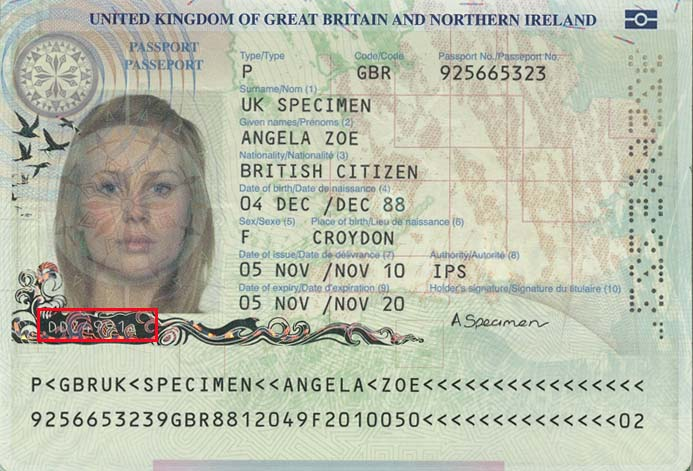

In [4]:
img_bgr = cv2.imread(str(IMG_PATH))
assert img_bgr is not None, f"Failed to load image: {IMG_PATH}"

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print("Loaded image shape:", img_bgr.shape)
Image.fromarray(img_rgb)


In [5]:
def preprocess_variants(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    variants = {}

    up2 = cv2.resize(gray, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
    up3 = cv2.resize(gray, None, fx=3.0, fy=3.0, interpolation=cv2.INTER_CUBIC)

    blur2 = cv2.GaussianBlur(up2, (3, 3), 0)
    blur3 = cv2.GaussianBlur(up3, (3, 3), 0)

    sharp3 = cv2.addWeighted(up3, 1.5, cv2.GaussianBlur(up3, (0, 0), 3), -0.5, 0)

    otsu2 = cv2.threshold(blur2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    otsu3 = cv2.threshold(blur3, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    inv_otsu2 = 255 - otsu2
    inv_otsu3 = 255 - otsu3

    adaptive2 = cv2.adaptiveThreshold(
        blur2, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 15
    )
    adaptive3 = cv2.adaptiveThreshold(
        blur3, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 15
    )

    morph2 = cv2.morphologyEx(otsu2, cv2.MORPH_CLOSE, np.ones((2, 2), np.uint8))
    morph3 = cv2.morphologyEx(otsu3, cv2.MORPH_CLOSE, np.ones((2, 2), np.uint8))

    variants["gray_up2"] = up2
    variants["gray_up3"] = up3
    variants["blur_up2"] = blur2
    variants["blur_up3"] = blur3
    variants["sharp_up3"] = sharp3
    variants["otsu_up2"] = otsu2
    variants["otsu_up3"] = otsu3
    variants["inv_otsu_up2"] = inv_otsu2
    variants["inv_otsu_up3"] = inv_otsu3
    variants["adaptive_up2"] = adaptive2
    variants["adaptive_up3"] = adaptive3
    variants["morph_up2"] = morph2
    variants["morph_up3"] = morph3

    return {k: cv2.cvtColor(v, cv2.COLOR_GRAY2BGR) for k, v in variants.items()}


In [6]:
def crop_candidates(image_bgr):
    h, w = image_bgr.shape[:2]

    crops = {
        "bottom_35": image_bgr[int(h * 0.65):h, 0:w],
        "bottom_40": image_bgr[int(h * 0.60):h, 0:w],
        "bottom_45": image_bgr[int(h * 0.55):h, 0:w],
        "bottom_50": image_bgr[int(h * 0.50):h, 0:w],
        "bottom_35_inner": image_bgr[int(h * 0.65):h, int(w * 0.03):int(w * 0.97)],
        "bottom_40_inner": image_bgr[int(h * 0.60):h, int(w * 0.03):int(w * 0.97)],
        "bottom_45_inner": image_bgr[int(h * 0.55):h, int(w * 0.03):int(w * 0.97)],
    }

    return crops


In [7]:
def normalize_mrz_text(text: str) -> str:
    return re.sub(r"[^A-Z0-9<]", "", str(text).upper().replace(" ", "").strip())

def cluster_ocr_lines(ocr_result, y_threshold=20):
    if not ocr_result or not ocr_result[0]:
        return []

    raw_items = []
    block = ocr_result[0]

    for box, text, score in zip(
        block["dt_polys"],
        block["rec_texts"],
        block["rec_scores"],
    ):
        y_center = sum(p[1] for p in box) / 4
        x_center = sum(p[0] for p in box) / 4
        raw_items.append({"text": text, "y": y_center, "x": x_center, "score": score})

    raw_items.sort(key=lambda k: k["y"])

    lines = []
    current = []

    for item in raw_items:
        if not current:
            current.append(item)
        else:
            avg_y = sum(i["y"] for i in current) / len(current)
            if abs(item["y"] - avg_y) < y_threshold:
                current.append(item)
            else:
                lines.append(current)
                current = [item]

    if current:
        lines.append(current)

    merged = []
    for line in lines:
        line.sort(key=lambda k: k["x"])
        merged.append(normalize_mrz_text("".join(x["text"] for x in line)))

    return [x for x in merged if len(x) >= 10]


In [ ]:
COMMON_CODES = {
    "ARE","IND","USA","GBR","CAN","AUS","DEU","FRA","ITA","ESP","NLD","BEL",
    "CHE","AUT","SWE","NOR","DNK","FIN","IRL","PRT","NZL","SGP","MYS","IDN",
    "PHL","THA","VNM","JPN","KOR","CHN","HKG","MAC","TWN","PAK","BGD","LKA",
    "NPL","AFG","SAU","QAT","KWT","OMN","BHR","JOR","EGY","TUR","ZAF","BRA",
    "ARG","MEX","RUS","UKR","POL","CZE","HUN","ROU","GRC","ISR","IRN","IRQ",
    "SYR","LBN","YEM","ETH","KEN","NGA","GHA","MAR","DZA","TUN","XXX","XXA",
    "XXB","XXC","UTO","EUE","UNO","UNA","UNK","RKS"
}

def clean_line1(line1: str) -> str:
    line1 = normalize_mrz_text(line1)

    if "P<" in line1 and not line1.startswith("P<"):
        line1 = line1[line1.find("P<"):]

    if len(line1) > 44:
        line1 = line1[:44]
    else:
        line1 = line1.ljust(44, "<")

    return line1


def clean_line2(line2: str) -> str:
    line2 = normalize_mrz_text(line2)

    if len(line2) > 44:
        line2 = line2[:44]
    else:
        line2 = line2.ljust(44, "<")

    return line2


In [10]:
def score_td3_pair(line1: str, line2: str):
    score = 0
    errors = []

    line1 = clean_line1(line1)
    line2 = clean_line2(line2)

    if len(line1) == 44:
        score += 40
    else:
        errors.append("bad_line1_len")

    if len(line2) == 44:
        score += 40
    else:
        errors.append("bad_line2_len")

    if line1.startswith("P<"):
        score += 60
    else:
        errors.append("line1_no_P<")

    if "<<" in line1[5:]:
        score += 25

    country1 = line1[2:5]
    nationality = line2[10:13]

    if country1 in COMMON_CODES:
        score += 30
    if nationality in COMMON_CODES:
        score += 30

    passport_no = line2[0:9]
    passport_cd = line2[9]
    birth = line2[13:19]
    birth_cd = line2[19]
    expiry = line2[21:27]
    expiry_cd = line2[27]
    personal = line2[28:42]
    personal_cd = line2[42]
    final_cd = line2[43]
    composite = line2[0:10] + line2[13:20] + line2[21:43]

    if passport_cd.isdigit() and mrz_checksum(passport_no) == passport_cd:
        score += 80
    else:
        errors.append("passport_cd_fail")

    if birth_cd.isdigit() and mrz_checksum(birth) == birth_cd:
        score += 80
    else:
        errors.append("birth_cd_fail")

    if expiry_cd.isdigit() and mrz_checksum(expiry) == expiry_cd:
        score += 80
    else:
        errors.append("expiry_cd_fail")

    if personal_cd == "<":
        score += 15
    elif personal_cd.isdigit() and mrz_checksum(personal) == personal_cd:
        score += 30
    else:
        errors.append("personal_cd_fail")

    if final_cd.isdigit() and mrz_checksum(composite) == final_cd:
        score += 100
    else:
        errors.append("final_cd_fail")

    return {
        "score": score,
        "line1": line1,
        "line2": line2,
        "errors": errors,
    }


In [11]:
all_candidates = []

# one focused crop, one OCR pass
crop = crop_candidates(img_bgr)["bottom_40_inner"]

# one lean preprocess path
gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
up2 = cv2.resize(gray, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
blur2 = cv2.GaussianBlur(up2, (3, 3), 0)
variant = cv2.cvtColor(blur2, cv2.COLOR_GRAY2BGR)

result = omni.ocr.predict(variant)
lines = cluster_ocr_lines(result)

assert len(lines) >= 2, f"Not enough OCR lines found: {lines}"

candidate_pairs = []
candidate_pairs.append((lines[-2], lines[-1]))
if len(lines) >= 3:
    candidate_pairs.append((lines[-3], lines[-2]))
    candidate_pairs.append((lines[-3], lines[-1]))

for l1, l2 in candidate_pairs:
    candidate = score_td3_pair(l1, l2)
    candidate["crop_name"] = "bottom_40_inner"
    candidate["variant_name"] = "single_blur_up2"
    all_candidates.append(candidate)

best = sorted(all_candidates, key=lambda x: x["score"], reverse=True)[0]
best


NameError: name 'COMMON_CODES' is not defined

In [ ]:
best_line1 = best["line1"]
best_line2 = best["line2"]

print("Best crop:", best["crop_name"])
print("Best variant:", best["variant_name"])
print("Best score:", best["score"])
print("Errors:", best["errors"])
print()
print(best_line1)
print(best_line2)


Best crop: bottom_40_inner
Best variant: single_blur_up2
Best score: 505
Errors: ['line1_no_P<']

<GBRUK<SPECIMEN<<ANGELA<ZOE<<<<<<<<<<<<<<<<<
9256653239GBR8812049F2010050<<<<<<<<<<<<<<02


In [ ]:
mrz_result = {
    "status": "SUCCESS(extraction of mrz)",
    "line1": best_line1,
    "line2": best_line2,
}

structural = structural_mrz_validation(mrz_result)
mrz_type = structural.get("mrz_type")

checksum = checksum_mrz_validation(mrz_result, mrz_type)
parsed_data = parse_mrz_fields(mrz_result, mrz_type)
logical = logical_mrz_validation(parsed_data, mrz_type)

result = {
    "extraction": mrz_result,
    "structural_validation": structural,
    "checksum_validation": checksum,
    "parsed_data": parsed_data,
    "logical_validation": logical,
    "candidate_meta": {
        "crop_name": best["crop_name"],
        "variant_name": best["variant_name"],
        "score": best.get("score"),
        "errors": best.get("errors"),
    }
}

pprint(result)


{'candidate_meta': {'crop_name': 'bottom_40_inner',
                    'errors': ['line1_no_P<'],
                    'score': 505,
                    'variant_name': 'single_blur_up2'},
 'checksum_validation': {'errors': [], 'status': 'PASS'},
 'extraction': {'line1': '<GBRUK<SPECIMEN<<ANGELA<ZOE<<<<<<<<<<<<<<<<<',
                'line2': '9256653239GBR8812049F2010050<<<<<<<<<<<<<<02',
                'status': 'SUCCESS(extraction of mrz)'},
 'logical_validation': {'errors': ['DOCUMENT_EXPIRED'], 'status': 'FAIL'},
 'parsed_data': {'data': {'date_of_birth': '1988-12-04',
                          'document_number': '925665323',
                          'document_type': 'G',
                          'expiry_date': '2020-10-05',
                          'gender': 'F',
                          'given_names': 'ANGELA ZOE',
                          'issuing_country': 'BRU',
                          'nationality': 'GBR',
                          'personal_number': '',
            

In [ ]:
import pytesseract

def clean_tesseract_mrz(text: str) -> str:
    text = str(text).upper().replace(" ", "").replace("\n", "")
    return re.sub(r"[^A-Z0-9<]", "", text)

crop = crop_candidates(img_bgr)["bottom_40_inner"]

gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
up2 = cv2.resize(gray, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
blur2 = cv2.GaussianBlur(up2, (3, 3), 0)
omni_variant = cv2.cvtColor(blur2, cv2.COLOR_GRAY2BGR)

omni_result = omni.ocr.predict(omni_variant)
omni_lines = cluster_ocr_lines(omni_result)

assert len(omni_lines) >= 2, f"Not enough Omni lines found: {omni_lines}"

omni_line1_candidates = [clean_line1(omni_lines[-2])]
if len(omni_lines) >= 3:
    omni_line1_candidates.append(clean_line1(omni_lines[-3]))

best_line1 = sorted(
    omni_line1_candidates,
    key=lambda x: (x.startswith("P<"), "<<" in x[5:], len(x)),
    reverse=True
)[0]

h, w = crop.shape[:2]
line2_roi = crop[int(h * 0.45):h, 0:w]

line2_gray = cv2.cvtColor(line2_roi, cv2.COLOR_BGR2GRAY)
line2_up = cv2.resize(line2_gray, None, fx=3.0, fy=3.0, interpolation=cv2.INTER_CUBIC)
line2_blur = cv2.GaussianBlur(line2_up, (3, 3), 0)
line2_bin = cv2.threshold(line2_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

tess_config = "--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789<"
tess_text = pytesseract.image_to_string(line2_bin, config=tess_config)

best_line2 = clean_line2(clean_tesseract_mrz(tess_text))

best = {
    "crop_name": "bottom_40_inner",
    "variant_name": "omni_line1_tesseract_line2",
    "line1": best_line1,
    "line2": best_line2,
}

best


{'crop_name': 'bottom_40_inner',
 'variant_name': 'omni_line1_tesseract_line2',
 'line1': '<GBRUK<SPECIMEN<<ANGELA<ZOE<<<<<<<<<<<<<<<<<',
 'line2': '<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'}

In [ ]:
best_line1 = best["line1"]
best_line2 = best["line2"]

print("Best crop:", best["crop_name"])
print("Best variant:", best["variant_name"])
print()
print(best_line1)
print(best_line2)

mrz_result = {
    "status": "SUCCESS(extraction of mrz)",
    "line1": best_line1,
    "line2": best_line2,
}

structural = structural_mrz_validation(mrz_result)
mrz_type = structural.get("mrz_type")
checksum = checksum_mrz_validation(mrz_result, mrz_type)
parsed_data = parse_mrz_fields(mrz_result, mrz_type)
logical = logical_mrz_validation(parsed_data, mrz_type)

result = {
    "extraction": mrz_result,
    "structural_validation": structural,
    "checksum_validation": checksum,
    "parsed_data": parsed_data,
    "logical_validation": logical,
    "candidate_meta": {
        "crop_name": best["crop_name"],
        "variant_name": best["variant_name"],
    },
}

pprint(result)


Best crop: bottom_40_inner
Best variant: omni_line1_tesseract_line2

<GBRUK<SPECIMEN<<ANGELA<ZOE<<<<<<<<<<<<<<<<<
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
{'candidate_meta': {'crop_name': 'bottom_40_inner',
                    'variant_name': 'omni_line1_tesseract_line2'},
 'checksum_validation': {'errors': ['CHECKSUM_FAIL',
                                    'CHECKSUM_FAIL',
                                    'CHECKSUM_FAIL',
                                    'CHECKSUM_FAIL'],
                         'status': 'FAIL'},
 'extraction': {'line1': '<GBRUK<SPECIMEN<<ANGELA<ZOE<<<<<<<<<<<<<<<<<',
                'line2': '<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<',
                'status': 'SUCCESS(extraction of mrz)'},
 'logical_validation': {'errors': [], 'status': 'PASS'},
 'parsed_data': {'data': {'date_of_birth': None,
                          'document_number': '',
                          'document_type': 'G',
                          'expiry_date': None,
            